# Documentation flow


# Neutron Star Simulation Documentation

This Python document contains the full code for the simulations and the majority of the graphs used in the research.

## Contents

### Simulations for Isolated Cases

- Limiting rotational frequency for a neutron star with a mass of 1.4 solar masses
  - Braking coefficients

- Limiting rotational frequency at the Keplerian limit
  - Maximum braking coefficients
---

### Simulations for Binary Cases

- Maximum transfer of angular frequency through accretion from 1.4 to 2.0 solar masses

- Normalized frequency vs. radius for millisecond neutron star observations

- Normalized limiting initial frequency vs. radius with variations in normalized accretion rates

---

## General Comments

- Units used throughout the simulations are SI units.
---

## Notable Constants Used in the Simulations

- **Gravitational constant**
  6.67430e-11
-  **Magnetic field strength**
   1e12 * 1e-4   Tesla
-  **Factor**
  0.4
-  **Eddington limit**
  8.7e14  kg/s

# Simulations for Isolated Cases

## Limiting rotational frequency for a neutron star

In [10]:
from scipy.linalg import solve as scipy_solve
from sympy import symbols, Eq, solve, init_printing, latex, Rational, Function, cos, sin,  diff
import sympy as sp
import numpy as np
import pandas as pd
import math

In [16]:

#Varables that will be used symbollically in our eqautions
A, B, a, b, R, Rprime, R0,v_k, c_t, ang, theta = symbols(' A B a b RNS RNSprime R_o Vₖ Cₜ x theta')

#Constants
G = 6.67430e-11

TurnSolar = 0
while TurnSolar < 3:
    

    if TurnSolar == 0:
        SolarMass = 1.4
        M =  1.98849e30 * SolarMass
    elif TurnSolar == 1:
        SolarMass = 1.6
        M =  1.98849e30 * SolarMass
    elif TurnSolar == 2:
        SolarMass = 2.0
        M =  1.98849e30 * SolarMass

    turn = 0
    #Store the final results of the Freqcucny and Local Strain If the data is needed
    FArr = []
    StrainArr = []
    TotalArr = np.array([])
    ToalArr2 = np.array([])

    Radius = 10.0
    Ro = 10
    while Radius < 14:

        CrustPercent = 0.02
        while CrustPercent < 0.13:
            PrimeRadius = Radius - (Radius * CrustPercent)


            #Vk and OmegaK
            vk = math.sqrt(G*M/(Radius*1e3))
            omegak = vk/(Radius*1e3)


            #These are symbolically reprsetned
            a1 = a
            a2 = A * R0**2
            a3 = B/R0**3
            a4 = b/R0**5
            Unit_R = R/R0
            Unit_Rprime = Rprime/R0

            ang = 1
            #The equations for solving the constants A B a b. These are the boundary equations for the crust.
            #Solving for the constants allows us to find the loacl displacement of the crust 
            Eq_5 = Eq(a1 - Rational(8,21)*a2*Unit_R**2 - a3/(2* Unit_R**3) + Rational(8,3) * a4/Unit_R**5,0)
            Eq_6 = Eq(a1 - Rational(8,21)*a2*Unit_Rprime**2 - a3/(2* Unit_Rprime**3) + Rational(8,3) * a4/Unit_Rprime**5,0)
            Eq_7 = Eq(-2* (a1 - (3*a2/7)* Unit_R**2 + a3/(Unit_R**3) - (4*a4/Unit_R**5))  - Rational(2,5)* (v_k**2/c_t**2) * (a1 - (a2/7) * Unit_R**2 - a3/(2*Unit_R**3) + a4/Unit_R**5)
                        +Rational(2,3) * ang * (v_k**2)/c_t**2, a2* Unit_R**2 + (a3/Unit_R**3)) 

            Eq_8 = Eq(a1 + (a2/14)* (Unit_Rprime)**2 + Rational(3/2) *( a3/(Unit_Rprime)**3) - (4*a4/(Unit_Rprime)**5) , 0)

            #Subing in numercial values in the equations to get numerical values
            #we solve for the constants using a system of equations
            Eq_5s = Eq_5.subs({R:Radius, R0:Ro})
            Eq_6s = Eq_6.subs({ Rprime:PrimeRadius, R0:Ro})
            Eq_7s = Eq_7.subs({R:Radius, R0:Ro, c_t:1e6, v_k:vk})
            Eq_8s = Eq_8.subs({ Rprime:PrimeRadius, R0:Ro})
            solution = sp.solve({Eq_7s,Eq_8s,Eq_5s,Eq_6s}, {a,A,B,b})

            #Now these are resprected with real numbercial numbers
            A1 = solution[a]
            A2 = solution[A] * Ro**2
            A3 = solution[B]/Ro**3
            A4 = solution[b]/Ro**5

            #Unitized the R values
            Unit_R = PrimeRadius/ Ro

            #Angle of the equator
            angle = 90
            Rads = angle * (math.pi/180)


            P2 = (3* cos(theta)**2 -1)/2
            diffP2 = diff(P2, theta)

            #Tensor Components
            SigmaRR = (a1 - (3*a2/7) * (Unit_R**2) + (a3)/(Unit_R**3) - 4*(a4)/(Unit_R**5)) * P2
            SigmaThetaTheta = (Rational(1,2)*a1 - Rational(5,42)*a2*(Unit_R)**2 - Rational(1,3)* (a4)/(Unit_R**5)) + \
                                (-a1 + Rational(1,3)*a2*(Unit_R**2)- Rational(1,2)*(a3)/(Unit_R**3) + Rational(7,3)* a4/(Unit_R**5)) * P2

            SigmaPP = -(Rational(1,2)* a1 - Rational(5,42)*a2*(Unit_R)**2 - Rational(1,3)* a4/(Unit_R**5)) + \
                        (Rational(2,21) * a2 * (Unit_R**2) - Rational(1,2)* a3/(Unit_R**3) + Rational(5,3)* a4/(Unit_R**5)) * P2  

            SigmaRTheta = Rational(1/2)*(a1 - Rational(8,21)*a2 *Unit_R**2 -Rational(1,2)*a3*(Unit_R)**3 + Rational(8,3)*a4* (Unit_R)**5)* diffP2
            SimgaThetaP = 0 
            SimgaPR = 0

            #subing in for varables to get a numbercial numbers in the tensor componets 
            SigmaRR_Sub = SigmaRR.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})
            SigmaThetaTheta_Sub = SigmaThetaTheta.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})
            SigmaPP_Sub = SigmaPP.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})
            SigmaRTheta_Sub = SigmaRTheta.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})


            angle = SigmaThetaTheta_Sub- SigmaPP_Sub
            angle2 = SigmaThetaTheta_Sub - SigmaRR_Sub


            #Making sure they stay a datatype floats 
            Sigma11 = float(SigmaRR_Sub)
            Sigma12 = float(SigmaRTheta_Sub)
            Sigma22 =  float(SigmaThetaTheta_Sub)
            Sigma33 =  float(SigmaPP_Sub)


            #Finding the EigenValues
            #This is the strain tensor 
            SIGMA = np.array([[Sigma11, Sigma12, 0],
                        [Sigma12, Sigma22, 0],
                        [0,     0,   Sigma33]
                        ])

            eigenvalues, eigenvectors = np.linalg.eig(SIGMA)


            #Gets the minimum and maxium values of the tensor components
            mins= np.min(eigenvalues)
            maxs = np.max(eigenvalues)

            #Subtract to get the local strain angle
            LocalStrainValue = maxs - mins
            
            critial = 0.1
            alpha =  math.sqrt(2) * math.sqrt(critial  / LocalStrainValue)
            max_initial_frequency = (math.sqrt(2) * math.sqrt(critial  / LocalStrainValue) * omegak) / (2 * math.pi)
            FArr.append(max_initial_frequency )
            StrainArr.append(alpha)
            
            
            CrustPercent += 0.02
            TotalArr = np.vstack([FArr])
            TotalArr2 = np.vstack([StrainArr])


        Ro += 0.2
        CrustPercent = 0
        Radius += 0.2
        
    CrustArr = np.array([0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12])
    RadiusArr = np.linspace(10.0, 14.0, 21)
    TotalArr.shape = (21,6)

    FinalArr = np.column_stack((RadiusArr , TotalArr))
    Final = np.row_stack((CrustArr, FinalArr))

    df = pd.DataFrame(FinalArr)
    print('\n')
    # Set display options for pandas DataFrame
    pd.set_option('float_format', '{:.8f}'.format)

    print(f'Data Of {SolarMass}:')
    print(df)
    
    TurnSolar += 1




Data Of 1.4:
             0            1            2            3            4  \
0  10.00000000 808.69599866 787.09667845 766.04484266 745.54860400   
1  10.20000000 785.02784656 764.06072109 743.62505556 723.72872559   
2  10.40000000 762.49207951 742.12690144 722.27792554 702.95280165   
3  10.60000000 741.01427354 721.22278352 701.93295418 683.15222021   
4  10.80000000 720.52617760 701.28193934 682.52549037 664.26406012   
5  11.00000000 700.96509913 682.24335094 663.99614829 646.23052465   
6  11.20000000 682.27336057 664.05088140 646.29029263 628.99844045   
7  11.40000000 664.39781765 646.65280602 629.35758224 612.51881343   
8  11.60000000 647.28943137 630.00139569 613.15156472 596.74643418   
9  11.80000000 630.90288698 614.05254606 597.62931544 581.63952667   
10 12.00000000 615.19625398 598.76544666 582.75111557 567.15943490   
11 12.20000000 600.13068231 584.10228516 568.48016420 553.27034269   
12 12.40000000 585.67013015 570.02798246 554.78232056 539.93902283   
13 12

kf (Hz): [2169.7 1880.6 1650.5 1463.8 1309.8]


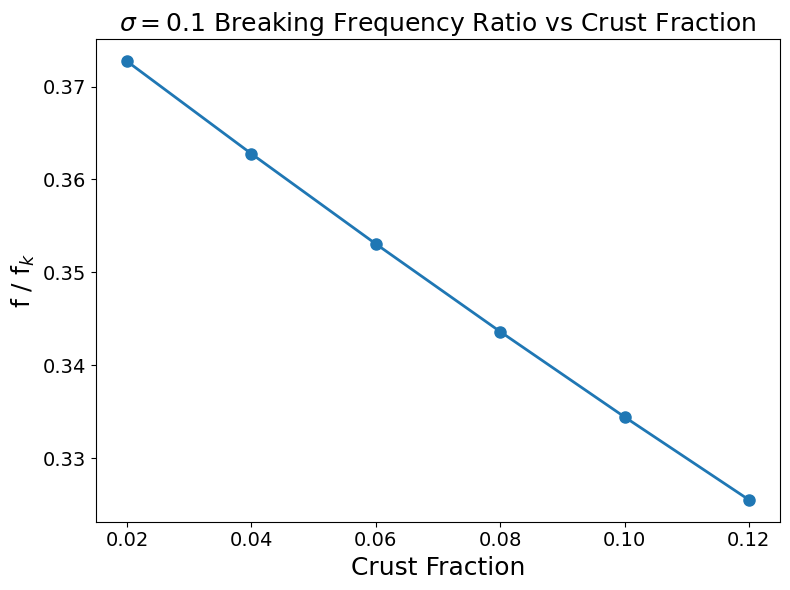

In [21]:
import numpy as np
import matplotlib.pyplot as plt

G     = 6.674e-11
M_sun = 1.989e30

#This function returns the nonreltavistic Keplerian frequency 
def keplerian_frequency(R):
    M = 1.4 * M_sun
    return (1 / (2 * np.pi)) * np.sqrt(G * M / R**3)


CrustArr = np.array([0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
radius   = np.array([10, 11, 12, 13, 14])   # km

#Output all the Keplerian frequncy in relation to it's repective radii
kf = keplerian_frequency(radius * 1e3)
print("kf (Hz):", np.round(kf, 1))

# k is the Keplerian frequncy at 10km 
# The ratio is the limiting frequncy for a NS at 1.4 solarmass 
# The breaking frequncy is invariant to change in radii. As a result normilzation of the frequncy at any radii 
# will results in the same.
# The breaking frequncy is sensative to the crust percentages. The larger the crust percentage the lower the limiting 
# frequncy, and vice versa. 

k = 2169.7
ratio = np.array([808.69599866, 787.09667845, 766.04484266, 745.54860400, 725.61565310, 706.25320621]) / k

plt.figure(figsize=(8,6))

plt.plot(CrustArr, ratio, marker='o', linewidth=2, markersize=8, label='f/fk')

# Bigger labels
plt.xlabel("Crust Fraction", fontsize=18)
plt.ylabel("f / f$_k$", fontsize=18)
plt.title(r"$\sigma=0.1$ Breaking Frequency Ratio vs Crust Fraction", fontsize=18)

# Bigger tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Bigger legend

plt.tight_layout()
plt.show()

# Limiting rotational frequency at the Keplerian limit

In [17]:
from scipy.linalg import solve as scipy_solve
from sympy import symbols, Eq, solve, init_printing, latex, Rational, Function, cos, sin,  diff
import sympy as sp
import numpy as np
import pandas as pd
import math

#Varables that will be used symbollically in our eqautions
A, B, a, b, R, Rprime, R0,v_k, c_t, ang, theta = symbols(' A B a b RNS RNSprime R_o Vₖ Cₜ x theta')

#Constants
G = 6.67430e-11

TurnSolar = 0
while TurnSolar < 3:
    

    if TurnSolar == 0:
        SolarMass = 1.4
        M =  1.98849e30 * SolarMass
    elif TurnSolar == 1:
        SolarMass = 1.6
        M =  1.98849e30 * SolarMass
    elif TurnSolar == 2:
        SolarMass = 2.0
        M =  1.98849e30 * SolarMass

    turn = 0
    #Store the final results of the Freqcucny and Local Strain If the data is needed
    FArr = []
    StrainArr = []
    TotalArr = np.array([])
    ToalArr2 = np.array([])

    Radius = 10.0
    Ro = 10
    while Radius < 14:

        CrustPercent = 0.02
        while CrustPercent < 0.13:
            PrimeRadius = Radius - (Radius * CrustPercent)


            #Vk and OmegaK
            vk = math.sqrt(G*M/(Radius*1e3))
            omegak = vk/(Radius*1e3)


            #These are symbolically reprsetned
            a1 = a
            a2 = A * R0**2
            a3 = B/R0**3
            a4 = b/R0**5
            Unit_R = R/R0
            Unit_Rprime = Rprime/R0

            ang = 1
            #The equations for solving the constants A B a b
            Eq_5 = Eq(a1 - Rational(8,21)*a2*Unit_R**2 - a3/(2* Unit_R**3) + Rational(8,3) * a4/Unit_R**5,0)
            Eq_6 = Eq(a1 - Rational(8,21)*a2*Unit_Rprime**2 - a3/(2* Unit_Rprime**3) + Rational(8,3) * a4/Unit_Rprime**5,0)
            Eq_7 = Eq(-2* (a1 - (3*a2/7)* Unit_R**2 + a3/(Unit_R**3) - (4*a4/Unit_R**5))  - Rational(2,5)* (v_k**2/c_t**2) * (a1 - (a2/7) * Unit_R**2 - a3/(2*Unit_R**3) + a4/Unit_R**5)
                        +Rational(2,3) * ang * (v_k**2)/c_t**2, a2* Unit_R**2 + (a3/Unit_R**3)) 

            Eq_8 = Eq(a1 + (a2/14)* (Unit_Rprime)**2 + Rational(3/2) *( a3/(Unit_Rprime)**3) - (4*a4/(Unit_Rprime)**5) , 0)

            #Subing in numercial values in the equations to get numerical values
            Eq_5s = Eq_5.subs({R:Radius, R0:Ro})
            Eq_6s = Eq_6.subs({ Rprime:PrimeRadius, R0:Ro})
            Eq_7s = Eq_7.subs({R:Radius, R0:Ro, c_t:1e6, v_k:vk})
            Eq_8s = Eq_8.subs({ Rprime:PrimeRadius, R0:Ro})
            solution = sp.solve({Eq_7s,Eq_8s,Eq_5s,Eq_6s}, {a,A,B,b})

            #Now these are resprected with real numbercial numbers
            A1 = solution[a]
            A2 = solution[A] * Ro**2
            A3 = solution[B]/Ro**3
            A4 = solution[b]/Ro**5

            #Unitized the R values
            Unit_R = PrimeRadius/ Ro

            #Angle of the equator
            angle = 90
            Rads = angle * (math.pi/180)


            P2 = (3* cos(theta)**2 -1)/2
            diffP2 = diff(P2, theta)

            #Tensor Components
            SigmaRR = (a1 - (3*a2/7) * (Unit_R**2) + (a3)/(Unit_R**3) - 4*(a4)/(Unit_R**5)) * P2
            SigmaThetaTheta = (Rational(1,2)*a1 - Rational(5,42)*a2*(Unit_R)**2 - Rational(1,3)* (a4)/(Unit_R**5)) + \
                                (-a1 + Rational(1,3)*a2*(Unit_R**2)- Rational(1,2)*(a3)/(Unit_R**3) + Rational(7,3)* a4/(Unit_R**5)) * P2

            SigmaPP = -(Rational(1,2)* a1 - Rational(5,42)*a2*(Unit_R)**2 - Rational(1,3)* a4/(Unit_R**5)) + \
                        (Rational(2,21) * a2 * (Unit_R**2) - Rational(1,2)* a3/(Unit_R**3) + Rational(5,3)* a4/(Unit_R**5)) * P2  

            SigmaRTheta = Rational(1/2)*(a1 - Rational(8,21)*a2 *Unit_R**2 -Rational(1,2)*a3*(Unit_R)**3 + Rational(8,3)*a4* (Unit_R)**5)* diffP2
            SimgaThetaP = 0 
            SimgaPR = 0

            #subing in for varables to get a numbercial numbers in the tensor componets 
            SigmaRR_Sub = SigmaRR.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})
            SigmaThetaTheta_Sub = SigmaThetaTheta.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})
            SigmaPP_Sub = SigmaPP.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})
            SigmaRTheta_Sub = SigmaRTheta.subs({a1: A1, a2: A2, a3: A3, a4: A4, theta: Rads})


            angle = SigmaThetaTheta_Sub- SigmaPP_Sub
            angle2 = SigmaThetaTheta_Sub - SigmaRR_Sub


            #Making sure they stay a datatype floats 
            Sigma11 = float(SigmaRR_Sub)
            Sigma12 = float(SigmaRTheta_Sub)
            Sigma22 =  float(SigmaThetaTheta_Sub)
            Sigma33 =  float(SigmaPP_Sub)


            #Finding the EigenValues
            SIGMA = np.array([[Sigma11, Sigma12, 0],
                        [Sigma12, Sigma22, 0],
                        [0,     0,   Sigma33]
                        ])

            eigenvalues, eigenvectors = np.linalg.eig(SIGMA)


            #Gets the minimum and maxium values of the tensor components
            mins= np.min(eigenvalues)
            maxs = np.max(eigenvalues)

            #Subtract to get the local strain angle
            LocalStrainValue = maxs - mins
            # print('\n',LocalStrainValue)
            
            # Unlike the other isolated case we are finding the stars final frequncy.
            # This is due to setting the Keplerian frequncy as it's intial frequncy.
            # This will tell us the maximual breaking and limiting frequncy.
            # KeplerF is the Keplerian frequncy and Omegaf is the change in frequncy.
            KeplerF = (1/(2*np.pi)) * np.sqrt(G*M/(Radius*1e3)**3)
            Omegaf = math.sqrt(2) * math.sqrt(0.1 / LocalStrainValue) * omegak
            max_initial_frequency = KeplerF - (Omegaf / (2 * math.pi))

            # print(f'Maximum Initial Frequency: {max_initial_frequency} Hz\n')
            FArr.append(max_initial_frequency)
            StrainArr.append(LocalStrainValue)

            CrustPercent += 0.02
            TotalArr = np.vstack([FArr])
            TotalArr2 = np.vstack([StrainArr])


        Ro += 0.2
        CrustPercent = 0
        Radius += 0.2
        
    CrustArr = np.array([0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12])
    RadiusArr = np.linspace(10.0, 14.0, 21)
    TotalArr.shape = (21,6)

    FinalArr = np.column_stack((RadiusArr , TotalArr))
    Final = np.row_stack((CrustArr, FinalArr))

    df = pd.DataFrame(Final)
    print('\n')
    # Set display options for pandas DataFrame
    pd.set_option('float_format', '{:.8f}'.format)

    print(f'Data Of {SolarMass}:')
    print(df)
    
    TurnSolar += 1






Data Of 1.4:
             0             1             2             3             4  \
0   0.00000000    0.02000000    0.04000000    0.06000000    0.08000000   
1  10.00000000 1360.74936414 1382.34868435 1403.40052014 1423.89675880   
2  10.20000000 1320.92410991 1341.89123538 1362.32690091 1382.22323088   
3  10.40000000 1283.00426639 1303.36944445 1323.21842035 1342.54354424   
4  10.60000000 1246.86460386 1266.65609388 1285.94592322 1304.72665719   
5  10.80000000 1212.39027950 1231.63451777 1250.39096674 1268.65239698   
6  11.00000000 1179.47580346 1198.19755165 1216.44475430 1234.21037793   
7  11.20000000 1148.02412442 1166.24660358 1184.00719236 1201.29904453   
8  11.40000000 1117.94581902 1135.69083065 1152.98605443 1169.82482324   
9  11.60000000 1089.15837165 1106.44640734 1123.29623831 1139.70136885   
10 11.80000000 1061.58553328 1078.43587420 1094.85910482 1110.84889359   
11 12.00000000 1035.15674946 1051.58755679 1067.60188788 1083.19356854   
12 12.20000000 1009.806

kf (Hz): [2169.7 1880.6 1650.5 1463.8 1309.8]


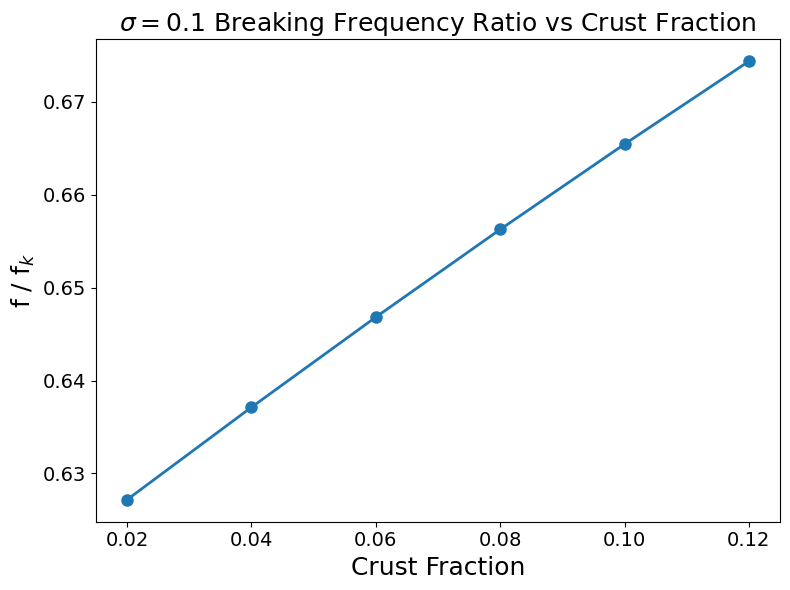

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# The same thing is happening for the breaking frequncy graph above here just for keplerian. 
# This is a graph based on sigma = 0.1

G     = 6.674e-11
M_sun = 1.989e30

def keplerian_frequency(R):
    M = 1.4 * M_sun
    return (1 / (2 * np.pi)) * np.sqrt(G * M / R**3)


CrustArr = np.array([0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
radius   = np.array([10, 11, 12, 13, 14])   # km

kf = keplerian_frequency(radius * 1e3)
print("kf (Hz):", np.round(kf, 1))

k = 2169.7
ratio = np.array([
    1360.74936414, 1382.34868435, 1403.40052014,
    1423.89675880, 1443.82970970, 1463.19215659
]) / k

plt.figure(figsize=(8,6))

plt.plot(CrustArr, ratio, marker='o', linewidth=2, markersize=8, label='f/fk')

# Bigger labels
plt.xlabel("Crust Fraction", fontsize=18)
plt.ylabel("f / f$_k$", fontsize=18)
plt.title(r"$\sigma=0.1$ Breaking Frequency Ratio vs Crust Fraction", fontsize=18)

# Bigger tick labels
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Bigger legend

plt.tight_layout()
plt.show()

kf (Hz): [2169.7 1880.6 1650.5 1463.8 1309.8]
0.7363280353182469,0.7697142146149238


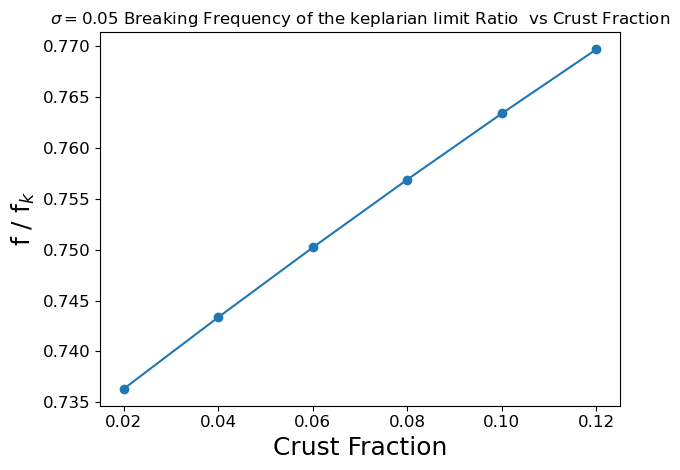

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# The same thing is happening for the breaking frequncy graph above here just for keplerian. 
# This is a graph based on sigma = 0.05

G     = 6.674e-11
M_sun = 1.989e30

def keplerian_frequency(R):
    M = 1.4 * M_sun
    return (1 / (2 * np.pi)) * np.sqrt(G * M / R**3)

CrustArr = np.array([0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
radius   = np.array([10, 11, 12, 13, 14])          # km

# FIX: compute kf for all radii
kf = keplerian_frequency(radius * 1e3)
print("kf (Hz):", np.round(kf, 1))

# keep your ratio idea but consistent
k = 2169.7
ratio = np.array([1597.61093823, 1612.88396402, 1627.76985986, 1642.26288921, 1656.35761396, 1670.04893145]) / k
mins = ratio.min()
maxs = ratio.max()
print(f"{mins},{maxs}")

#print(ratio)
plt.figure()

# FIX: label must match x-axis
plt.plot(CrustArr, ratio, marker='o', label='f/fk')

plt.xlabel("Crust Fraction", fontsize=18)
plt.ylabel("f / f$_k$", fontsize=18)
plt.title(r"$\sigma=0.05$ Breaking Frequency Ratio vs Crust Fraction", fontsize=20)
# Bigger tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.ylabel("f / f$_k$")
plt.xlabel("Crust Fraction")   # FIXED label
plt.title(r"$\sigma=0.05$ Breaking Frequency of the keplarian limit Ratio  vs Crust Fraction")
plt.tight_layout()
plt.show()


# Simulations for Binary Cases

# Maximum transfer of angular frequency through accretion from 1.4 to 2.0 solar masses


C:\Users\julio\AppData\Local\Temp\ipykernel_27644\257713738.py:36: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(radius, f1_high, '-o', color='blue', linestyle='--', label='1.4 M☉, ṁ=1')
C:\Users\julio\AppData\Local\Temp\ipykernel_27644\257713738.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(radius, f2_high, '-o', color='red', linestyle='--', label='2.0 M☉, ṁ=1')


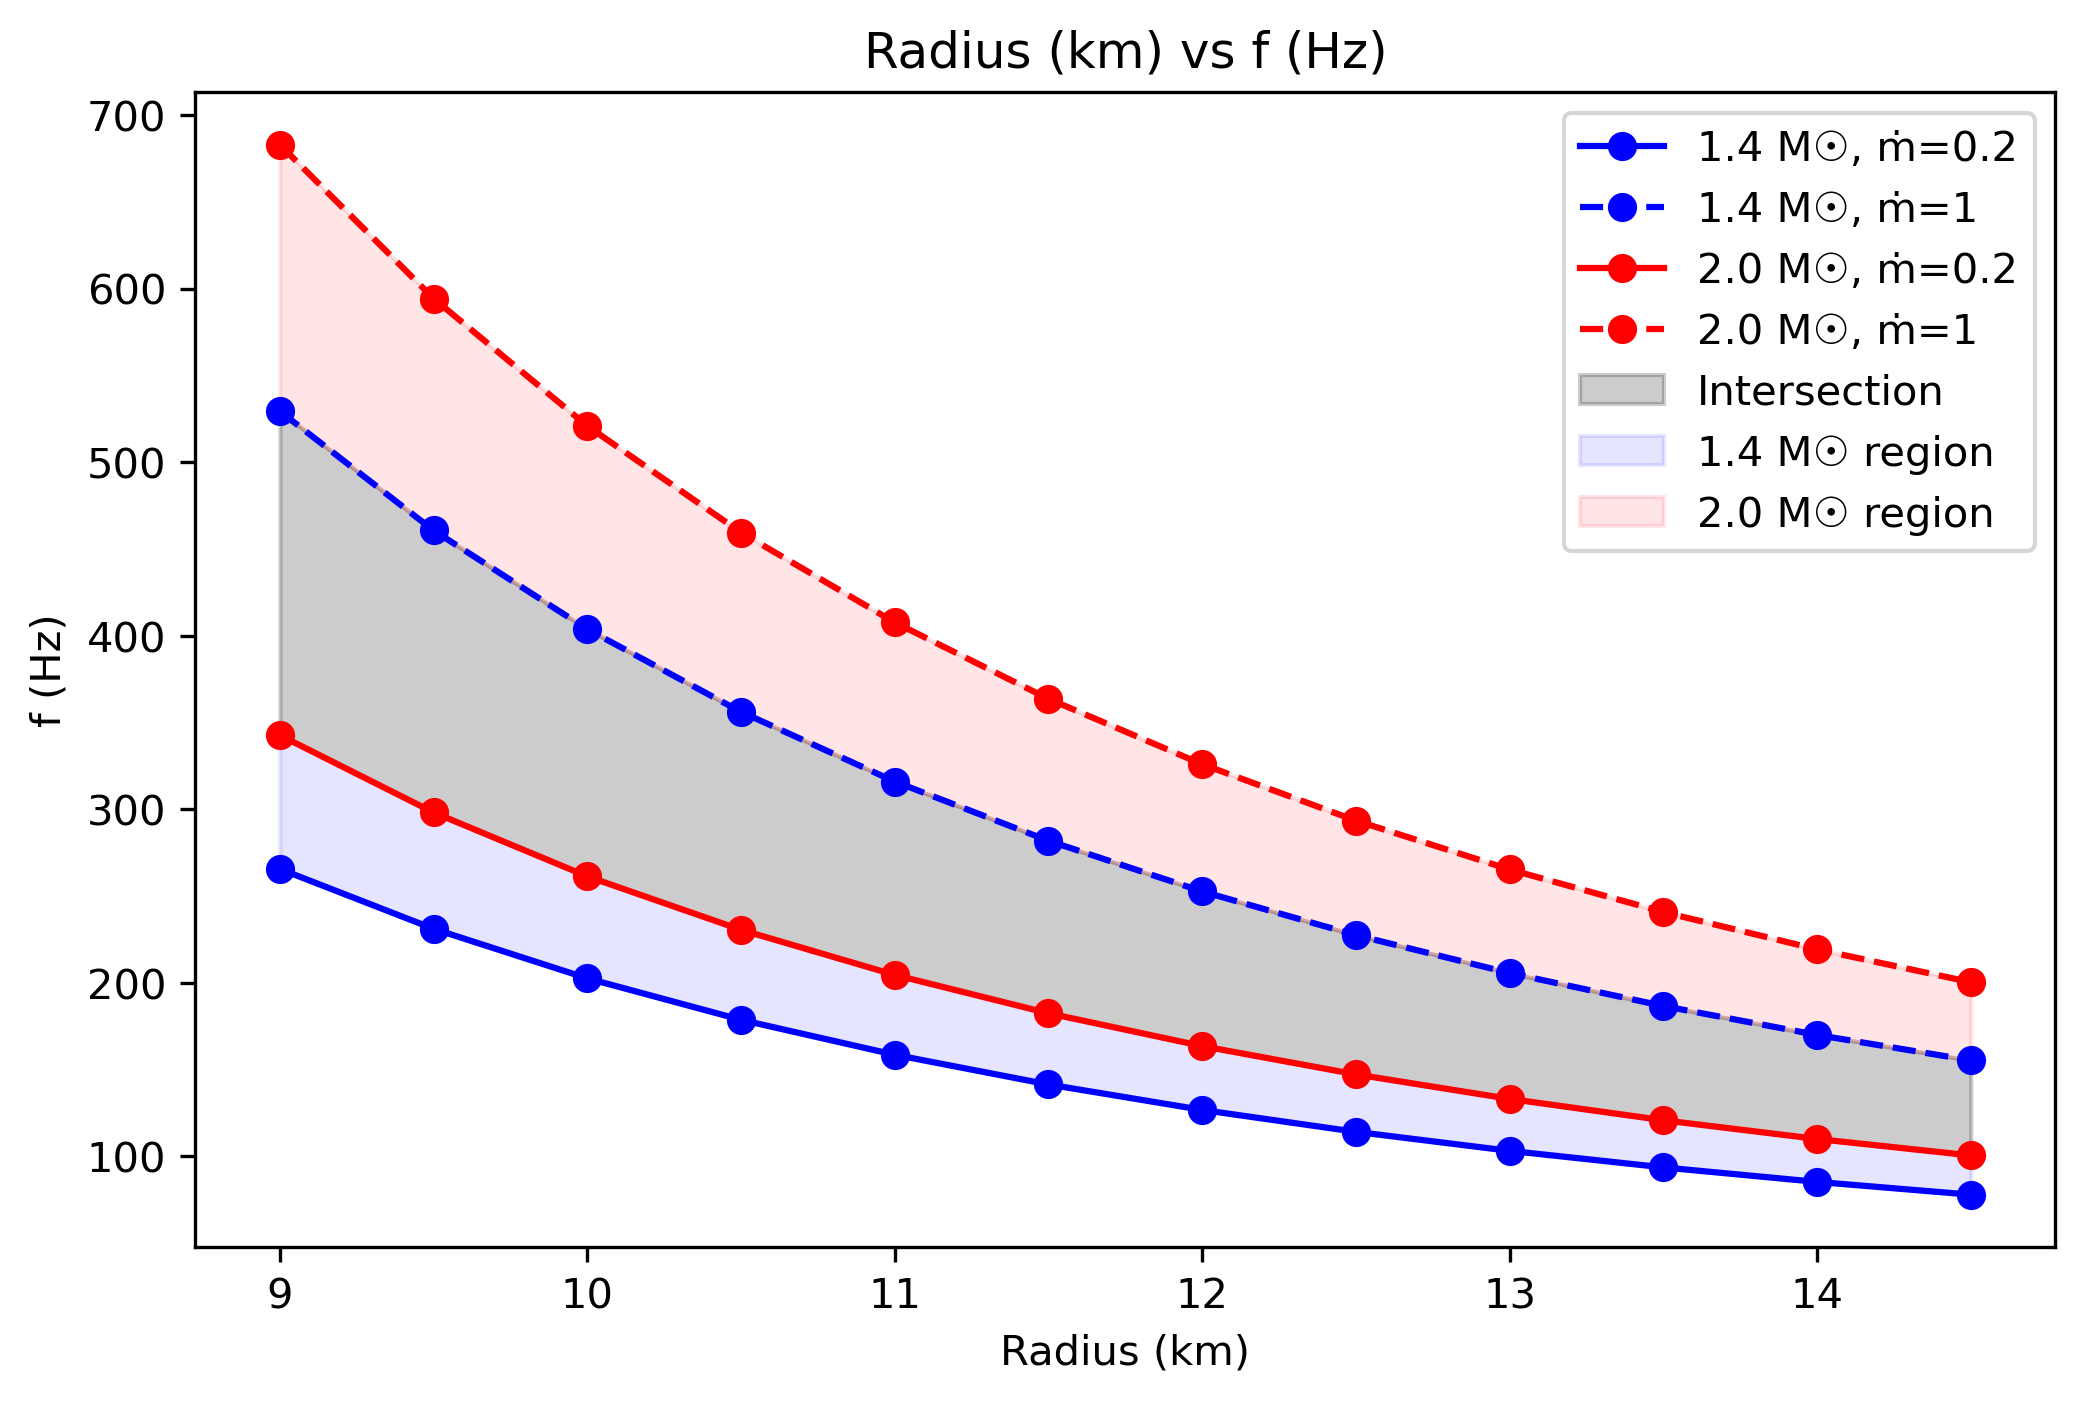

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# constants used in simulation 
G = 6.67430e-11
SolarMass = 1.98849e30
B = 1e12 * 1e-4
Factor = 0.4
M_edd = 8.7e14
radius = np.arange(9, 15, 0.5)

# This function computs the maxmiumal frequncy from accreation at accretion rate 0.2 and 1 percent of the eddigton limit
def compute_band(M):
    f_low, f_high = [], []

    for i in radius:
        R = i * 1e3
        mu = B * R**3

        ang_edd = Factor * np.sqrt(G*M) * ((2*G*M*M_edd**2 / mu**4)**(3/14))

        f_low.append((0.2**(3/7) * ang_edd) / (2*np.pi))
        f_high.append((1.0**(3/7) * ang_edd) / (2*np.pi))

    return np.array(f_low), np.array(f_high)

# compute for both masses
f1_low, f1_high = compute_band(1.4 * SolarMass)
f2_low, f2_high = compute_band(2.0 * SolarMass)

plt.figure(figsize=(8,5),dpi=300)

# plot boundary lines
plt.plot(radius, f1_low, '-o', color='blue', label='1.4 M☉, ṁ=0.2')
plt.plot(radius, f1_high, '-o', color='blue', linestyle='--', label='1.4 M☉, ṁ=1')

plt.plot(radius, f2_low, '-o', color='red', label='2.0 M☉, ṁ=0.2')
plt.plot(radius, f2_high, '-o', color='red', linestyle='--', label='2.0 M☉, ṁ=1')

# ---- intersection region ----
inter_low = np.maximum(f1_low, f2_low)
inter_high = np.minimum(f1_high, f2_high)
mask = inter_high > inter_low

plt.fill_between(radius, inter_low, inter_high,
                 where=mask, color='black', alpha=0.2,
                 label='Intersection')

# ---- mass 1 (1.4 M☉) non-overlap ----
plt.fill_between(radius, f1_low, inter_low,
                 where=(f1_low < inter_low),
                 color='blue', alpha=0.1)

plt.fill_between(radius, inter_high, f1_high,
                 where=(f1_high > inter_high),
                 color='blue', alpha=0.1,
                 label='1.4 M☉ region')

# ---- mass 2 (2.0 M☉) non-overlap ----
plt.fill_between(radius, f2_low, inter_low,
                 where=(f2_low < inter_low),
                 color='red', alpha=0.1)

plt.fill_between(radius, inter_high, f2_high,
                 where=(f2_high > inter_high),
                 color='red', alpha=0.1,
                 label='2.0 M☉ region')

plt.title('Radius (km) vs f (Hz)')
plt.xlabel('Radius (km)')
plt.ylabel('f (Hz)')
plt.legend()
plt.show()

# Normalized limiting initial frequency vs. radius with variations in normalized accretion rates

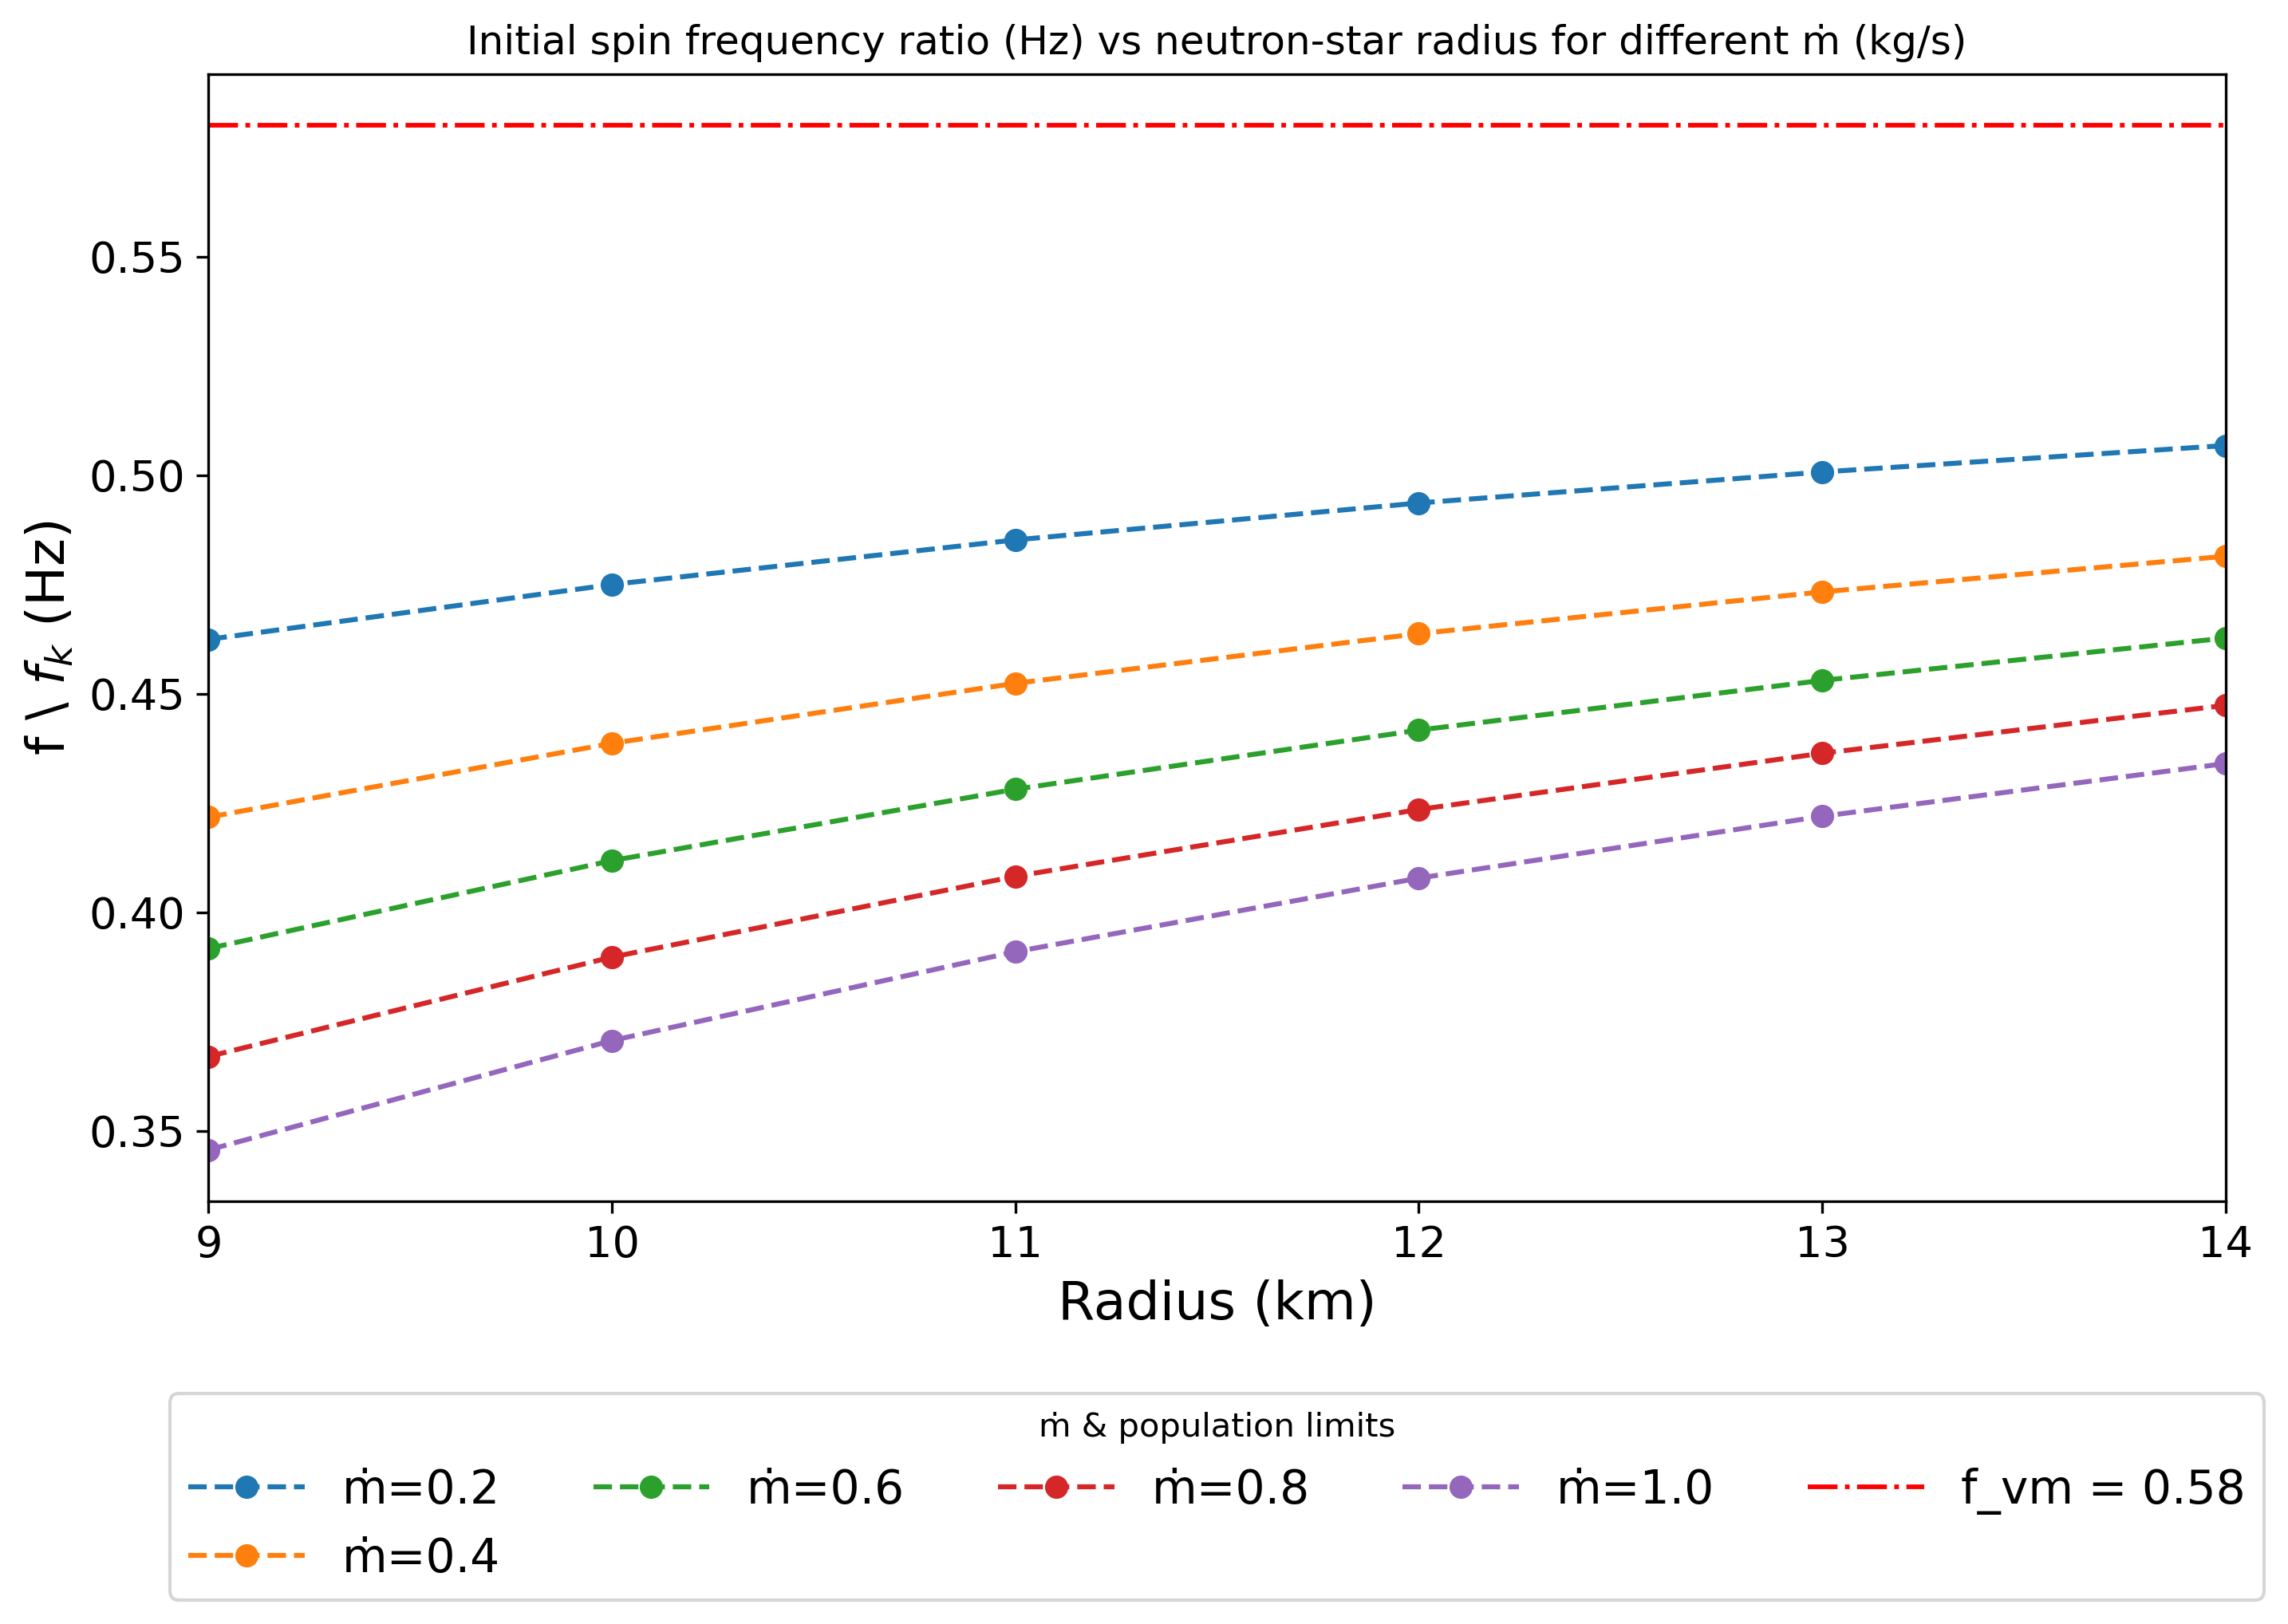

In [27]:
Mdot_edd = 8.7e14
# constants
G = 6.67430e-11
SolarMass = 1.98849e30
M = 1.4 * SolarMass
year = 3.154e7

# magnetic field (Tesla)
B = 1e12 * 1e-4
Factor = 0.45
freq_list = []
radius_list = []
e_vm = []
mdot_list = []
mdots_arr = [0.2,0.4,0.6,0.8,1]

low=[]
upper=[]
avg=[]
for i in  np.arange(9, 15, 1):
    for j in np.arange(0,5,1):
            
            R = i * 1e3  # meters
            mu = B * R**3
            # maxmiumal transferable frequncy from accretion 
            ang_edd = Factor * np.sqrt(G*M) * ((2*G*M*Mdot_edd**2 / mu**4)**(3/14))
            Omega_k = np.sqrt((G * M) / R**3)  # Keplerian angular frequency
            f_k = Omega_k/ (2*np.pi)
            #This is the normlized breaking frequncy.
            Omega_e = 0.58
            
            #boundary of observation lower limit population, max observed and average f in (hz)
            lower_val = 540
            upper_val = 619
            avg_val = 575

            PopBondary = lower_val / f_k
            PopMax = upper_val / f_k
            PopAvg = avg_val / f_k

            low.append(PopBondary)
            upper.append(PopMax)
            avg.append(PopAvg)
            
            delta_ang = (mdots_arr[j])**(3/7) * ang_edd
            ang_e = Omega_k * Omega_e
            ang_i = ang_e  - delta_ang
            
            f_i = ang_i / (2*np.pi)
            freq_list.append(f_i/f_k)
            radius_list.append(i)
            mdot_list.append(mdots_arr[j])

# convert to numpy
freq_list = np.array(freq_list)
radius_list = np.array(radius_list)
mdot_list = np.array(mdot_list)
fig, ax = plt.subplots(figsize=(10, 6.5),dpi=300)
# plot each mdot curve
for mdot in np.unique(mdot_list):
    mask = mdot_list == mdot
    plt.plot(radius_list[mask], freq_list[mask], '--o', label=f'ṁ={mdot}')

r_unique = np.arange(9, 15, 1)
ax.set_xlim(9, 14)
#ax.set_ylim(0, 1)
ax.set_xticks(np.arange(9, 15, 1))

#you can compare the intial frequncy with that of observational results
#ax.fill_between(r_unique, low[::5], upper[::5], color='red', alpha=0.08)
#ax.fill_between(r_unique, 0.65, 0.75, color='blue', alpha=0.08)
#ax.plot(r_unique, low[::5],   color='violet',    linewidth=1.4, linestyle='--', label='545 Hz')
#ax.plot(r_unique, avg[::5],   color='b', linewidth=1.4, linestyle='--', label='575 Hz')
#ax.plot(r_unique, upper[::5], color='violet',    linewidth=1.4, linestyle='--', label='619 Hz')
#ax.axhline(y=0.65, color='black', linewidth=1.4, linestyle='-.', label='f_f/fₖ')
#ax.axhline(y=0.75, color='black', linewidth=1.4, linestyle='-.', label='f_f/fₖ')

ax.set_xlim(9, 14)

ax.axhline(y=0.58, color='red', linewidth=1.4, linestyle='-.', label='f_vm = 0.58')
ax.set_xlabel('Radius (km)', fontsize=16)
ax.set_ylabel(r'f \ $f_k$ (Hz)',fontsize=16)
ax.set_title('Initial spin frequency ratio (Hz) vs neutron-star radius for different ṁ (kg/s)')
ax.set_xticks(np.arange(9, 15, 1))
ax.tick_params(axis='both', labelsize=13)
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    fontsize=14,
    frameon=True,
    title='ṁ & population limits',  
    handlelength=2.5
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

# Normalized frequency vs. radius for millisecond neutron star observations

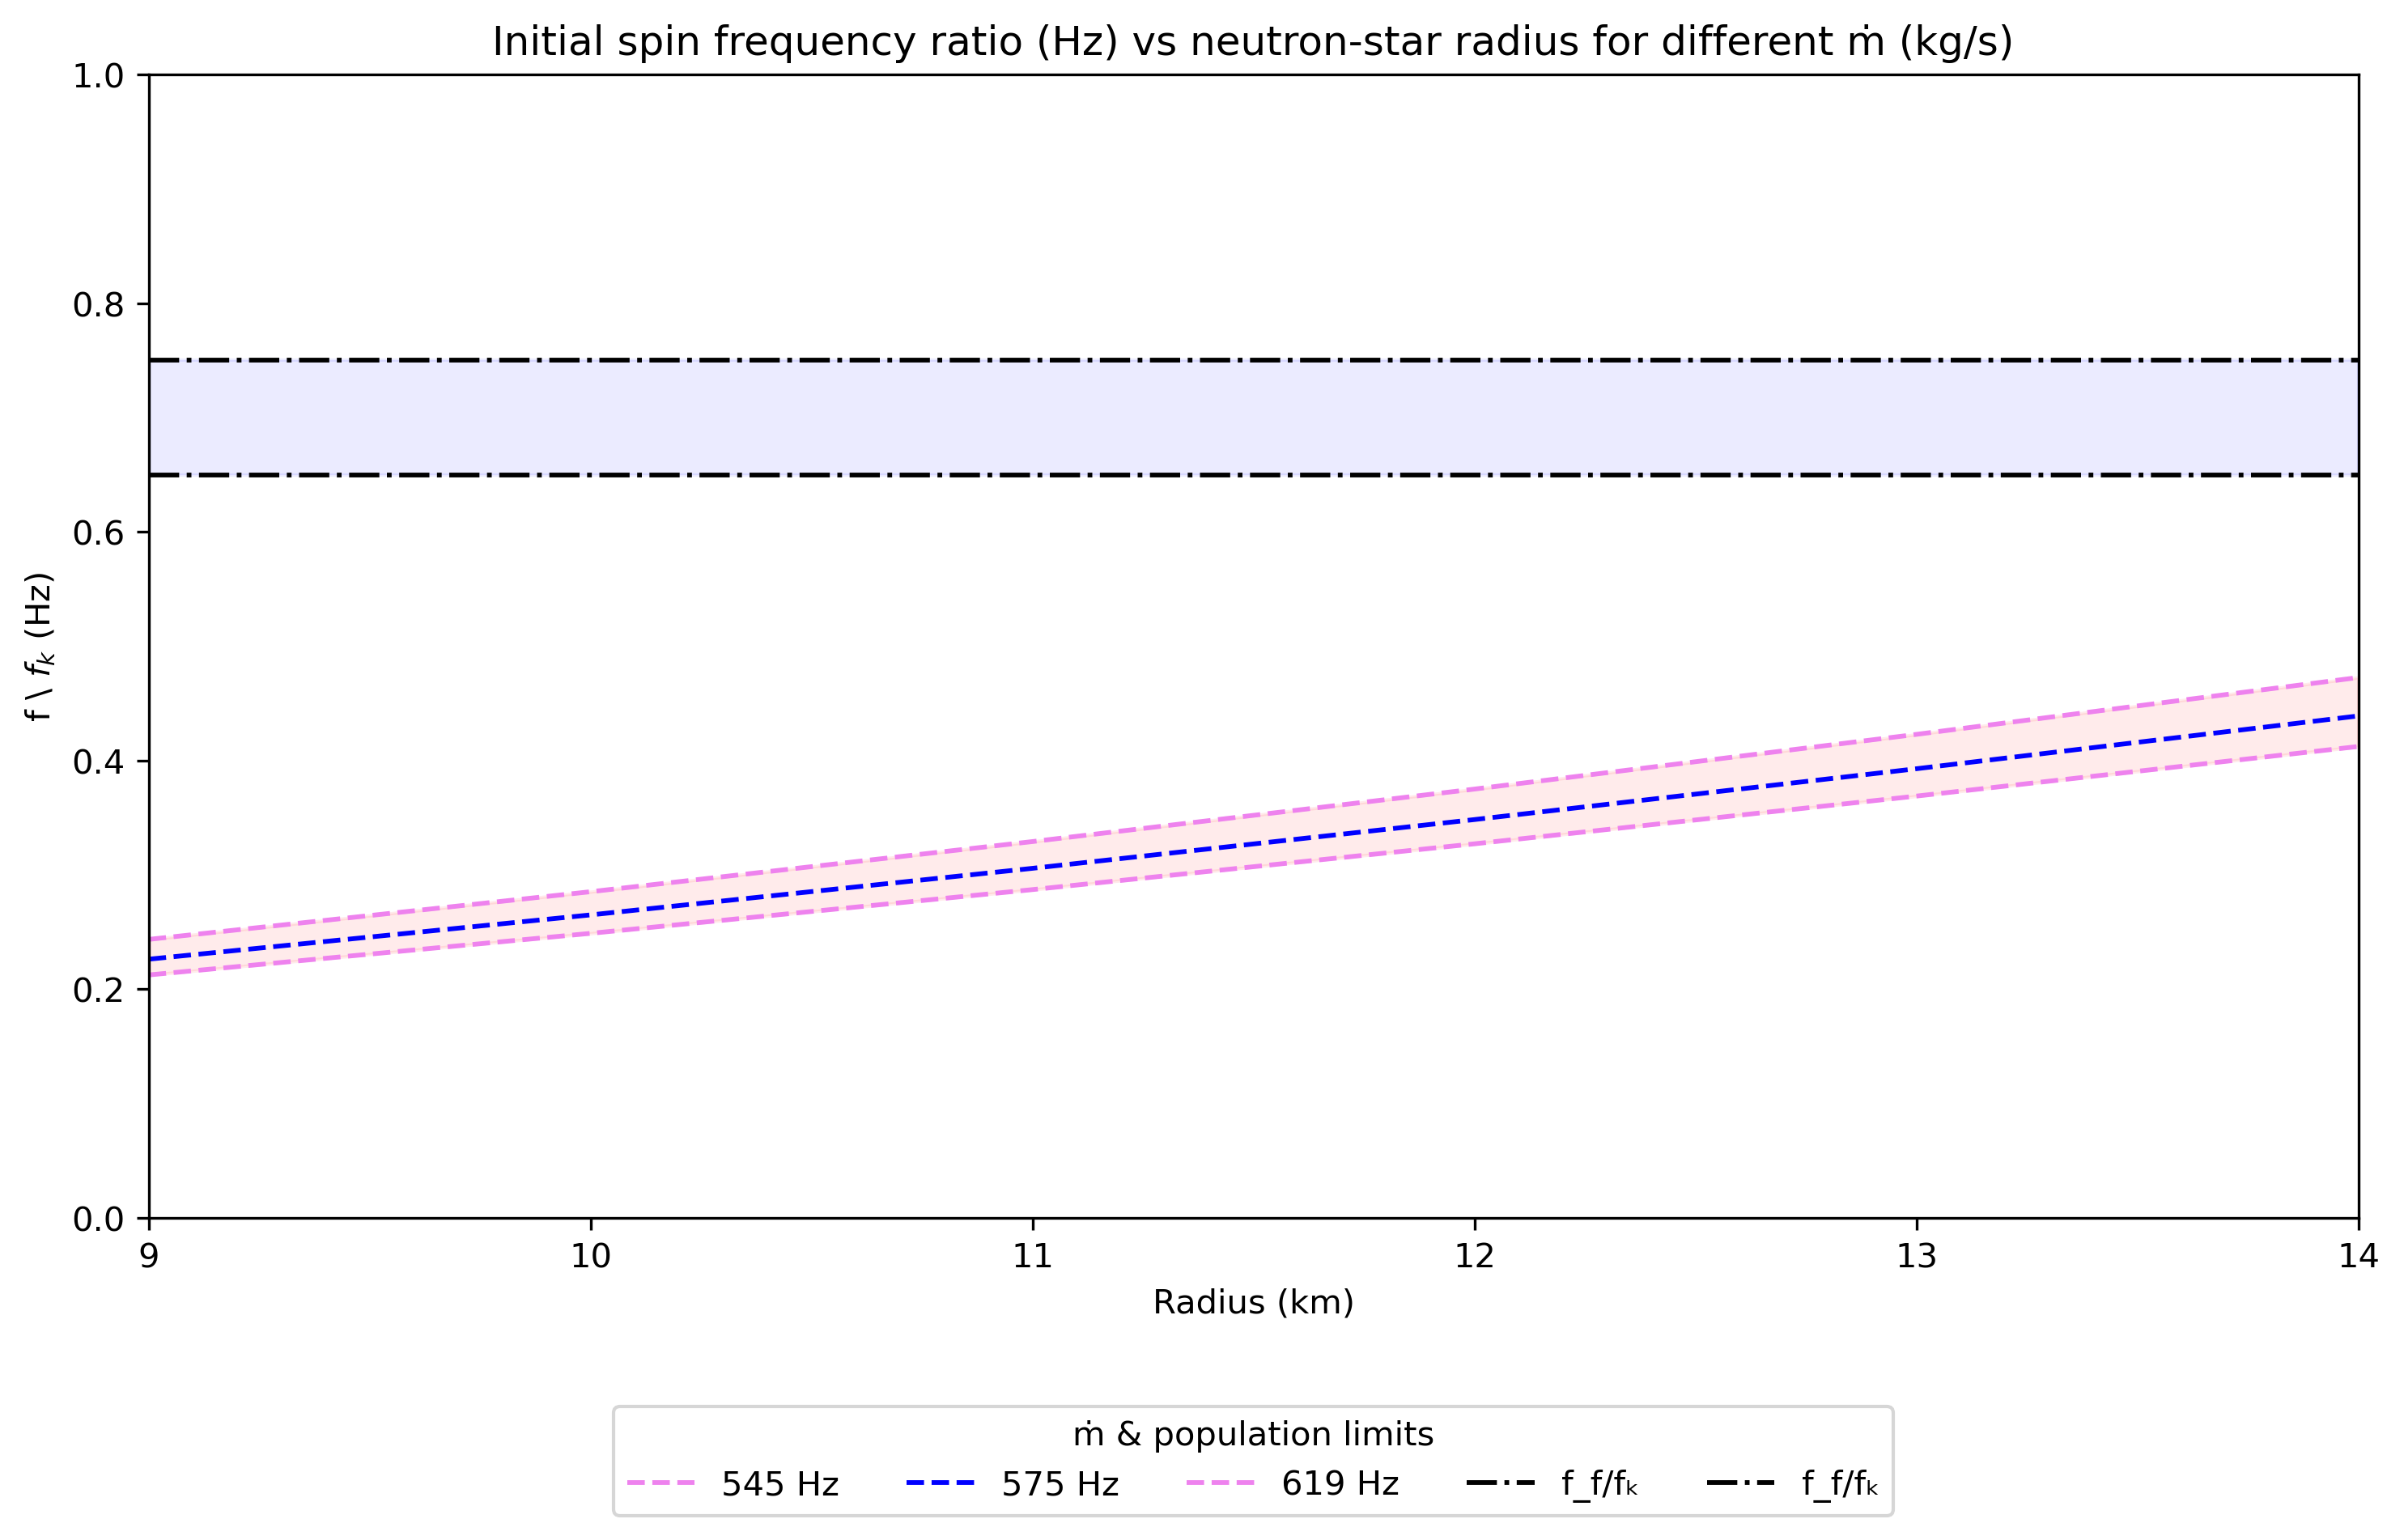

In [26]:
Mdot_edd = 8.7e14
# constants
G = 6.67430e-11
SolarMass = 1.98849e30
M = 1.4 * SolarMass
year = 3.154e7

# magnetic field (Tesla)
B = 1e12 * 1e-4
Factor = 0.45
freq_list = []
radius_list = []
e_vm = []
mdot_list = []
mdots_arr = [0.2,0.4,0.6,0.8,1]

low=[]
upper=[]
avg=[]
for i in  np.arange(9, 15, 1):
    for j in np.arange(0,5,1):
            
            R = i * 1e3  # meters
            mu = B * R**3
            ang_edd = Factor * np.sqrt(G*M) * ((2*G*M*Mdot_edd**2 / mu**4)**(3/14))
            Omega_k = np.sqrt((G * M) / R**3)  # Keplerian angular frequency
            f_k = Omega_k/ (2*np.pi)
            Omega_e = 0.58
            
            #boundary of observation lower limit population, max observed and average f in (hz)
            lower_val = 540
            upper_val = 619
            avg_val = 575

            PopBondary = lower_val / f_k
            PopMax = upper_val / f_k
            PopAvg = avg_val / f_k

            low.append(PopBondary)
            upper.append(PopMax)
            avg.append(PopAvg)
            
            delta_ang = (mdots_arr[j])**(3/7) * ang_edd
            ang_e = Omega_k * Omega_e
            ang_i = ang_e  - delta_ang
            
            f_i = ang_i / (2*np.pi)
            freq_list.append(f_i/f_k)
            radius_list.append(i)
            mdot_list.append(mdots_arr[j])

# convert to numpy
freq_list = np.array(freq_list)
radius_list = np.array(radius_list)
mdot_list = np.array(mdot_list)
fig, ax = plt.subplots(figsize=(10, 6.5),dpi=300)
#plot each mdot curve
for mdot in np.unique(mdot_list):
    mask = mdot_list == mdot
   # plt.plot(radius_list[mask], freq_list[mask], '--o', label=f'ṁ={mdot}')

r_unique = np.arange(9, 15, 1)
ax.set_xlim(9, 14)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(9, 15, 1))
ax.fill_between(r_unique, low[::5], upper[::5], color='red', alpha=0.08)
ax.fill_between(r_unique, 0.65, 0.75, color='blue', alpha=0.08)
ax.plot(r_unique, low[::5],   color='violet',    linewidth=1.4, linestyle='--', label='545 Hz')
ax.plot(r_unique, avg[::5],   color='b', linewidth=1.4, linestyle='--', label='575 Hz')
ax.plot(r_unique, upper[::5], color='violet',    linewidth=1.4, linestyle='--', label='619 Hz')
ax.axhline(y=0.65, color='black', linewidth=1.4, linestyle='-.', label='f_f/fₖ')
ax.axhline(y=0.75, color='black', linewidth=1.4, linestyle='-.', label='f_f/fₖ')

ax.set_xlabel('Radius (km)')
ax.set_ylabel(r'f \ $f_k$ (Hz)')
ax.set_title('Initial spin frequency ratio (Hz) vs neutron-star radius for different ṁ (kg/s)')
ax.set_xticks(np.arange(9, 15, 1))
ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=True,
    title='ṁ & population limits'
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()
